In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Loading and Preprocessing the Diabetes dataset from sklearn
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target

# Checking for missing values and normalizing the features using StandardScaler
print(f"Missing values in X: {np.any(np.isnan(X))}")
print(f"Missing values in y: {np.any(np.isnan(y))}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Missing values in X: False
Missing values in y: False


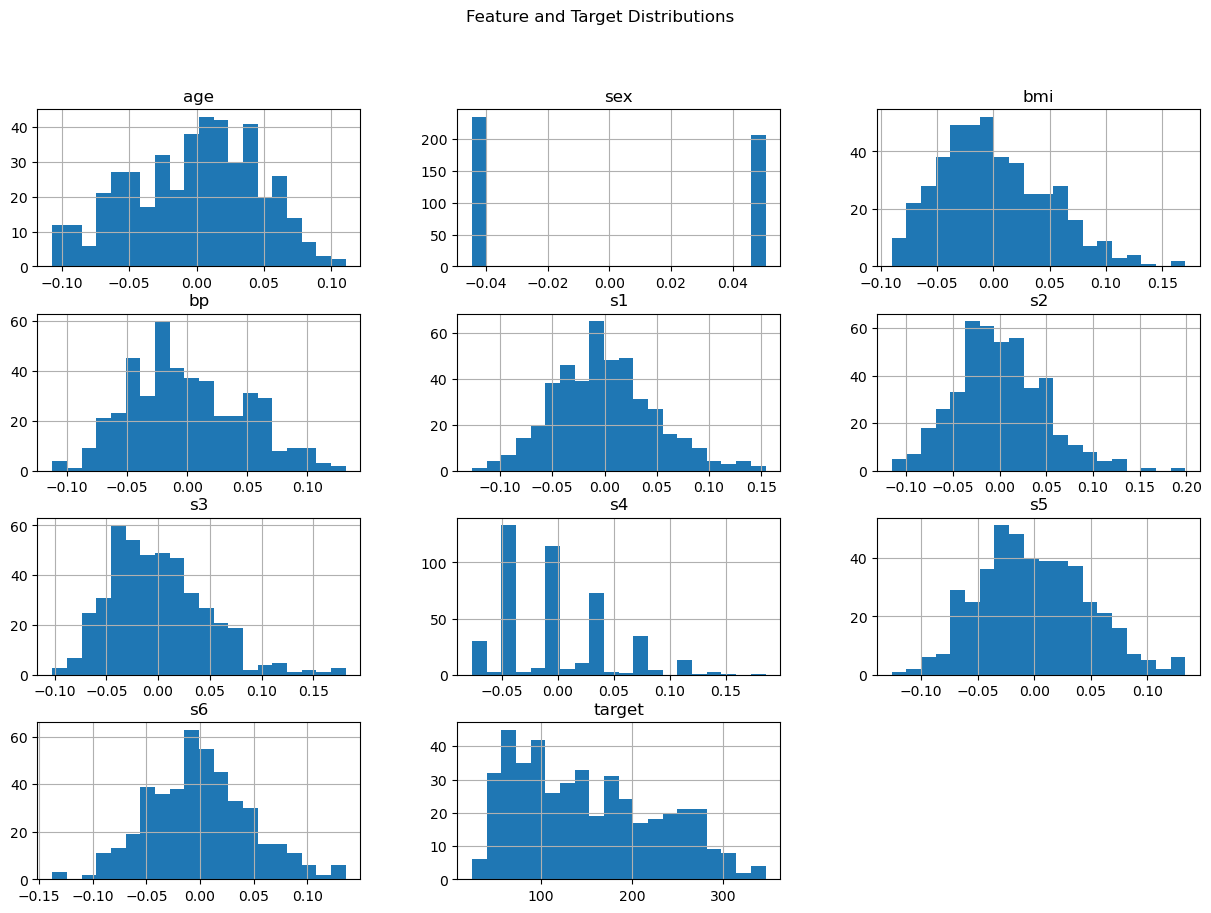

In [3]:
# 2. Exploratory Data Analysis (EDA)
# Converting to DataFrame for easier visualization
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

# Visualizing the distribution of features and target variable
df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Feature and Target Distributions")
plt.show()

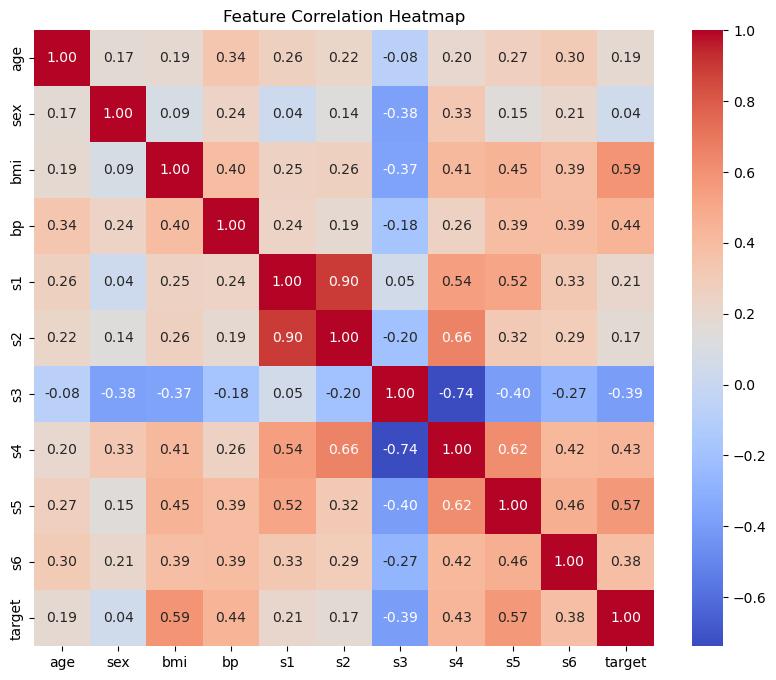

In [5]:
# Heatmap of feature correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

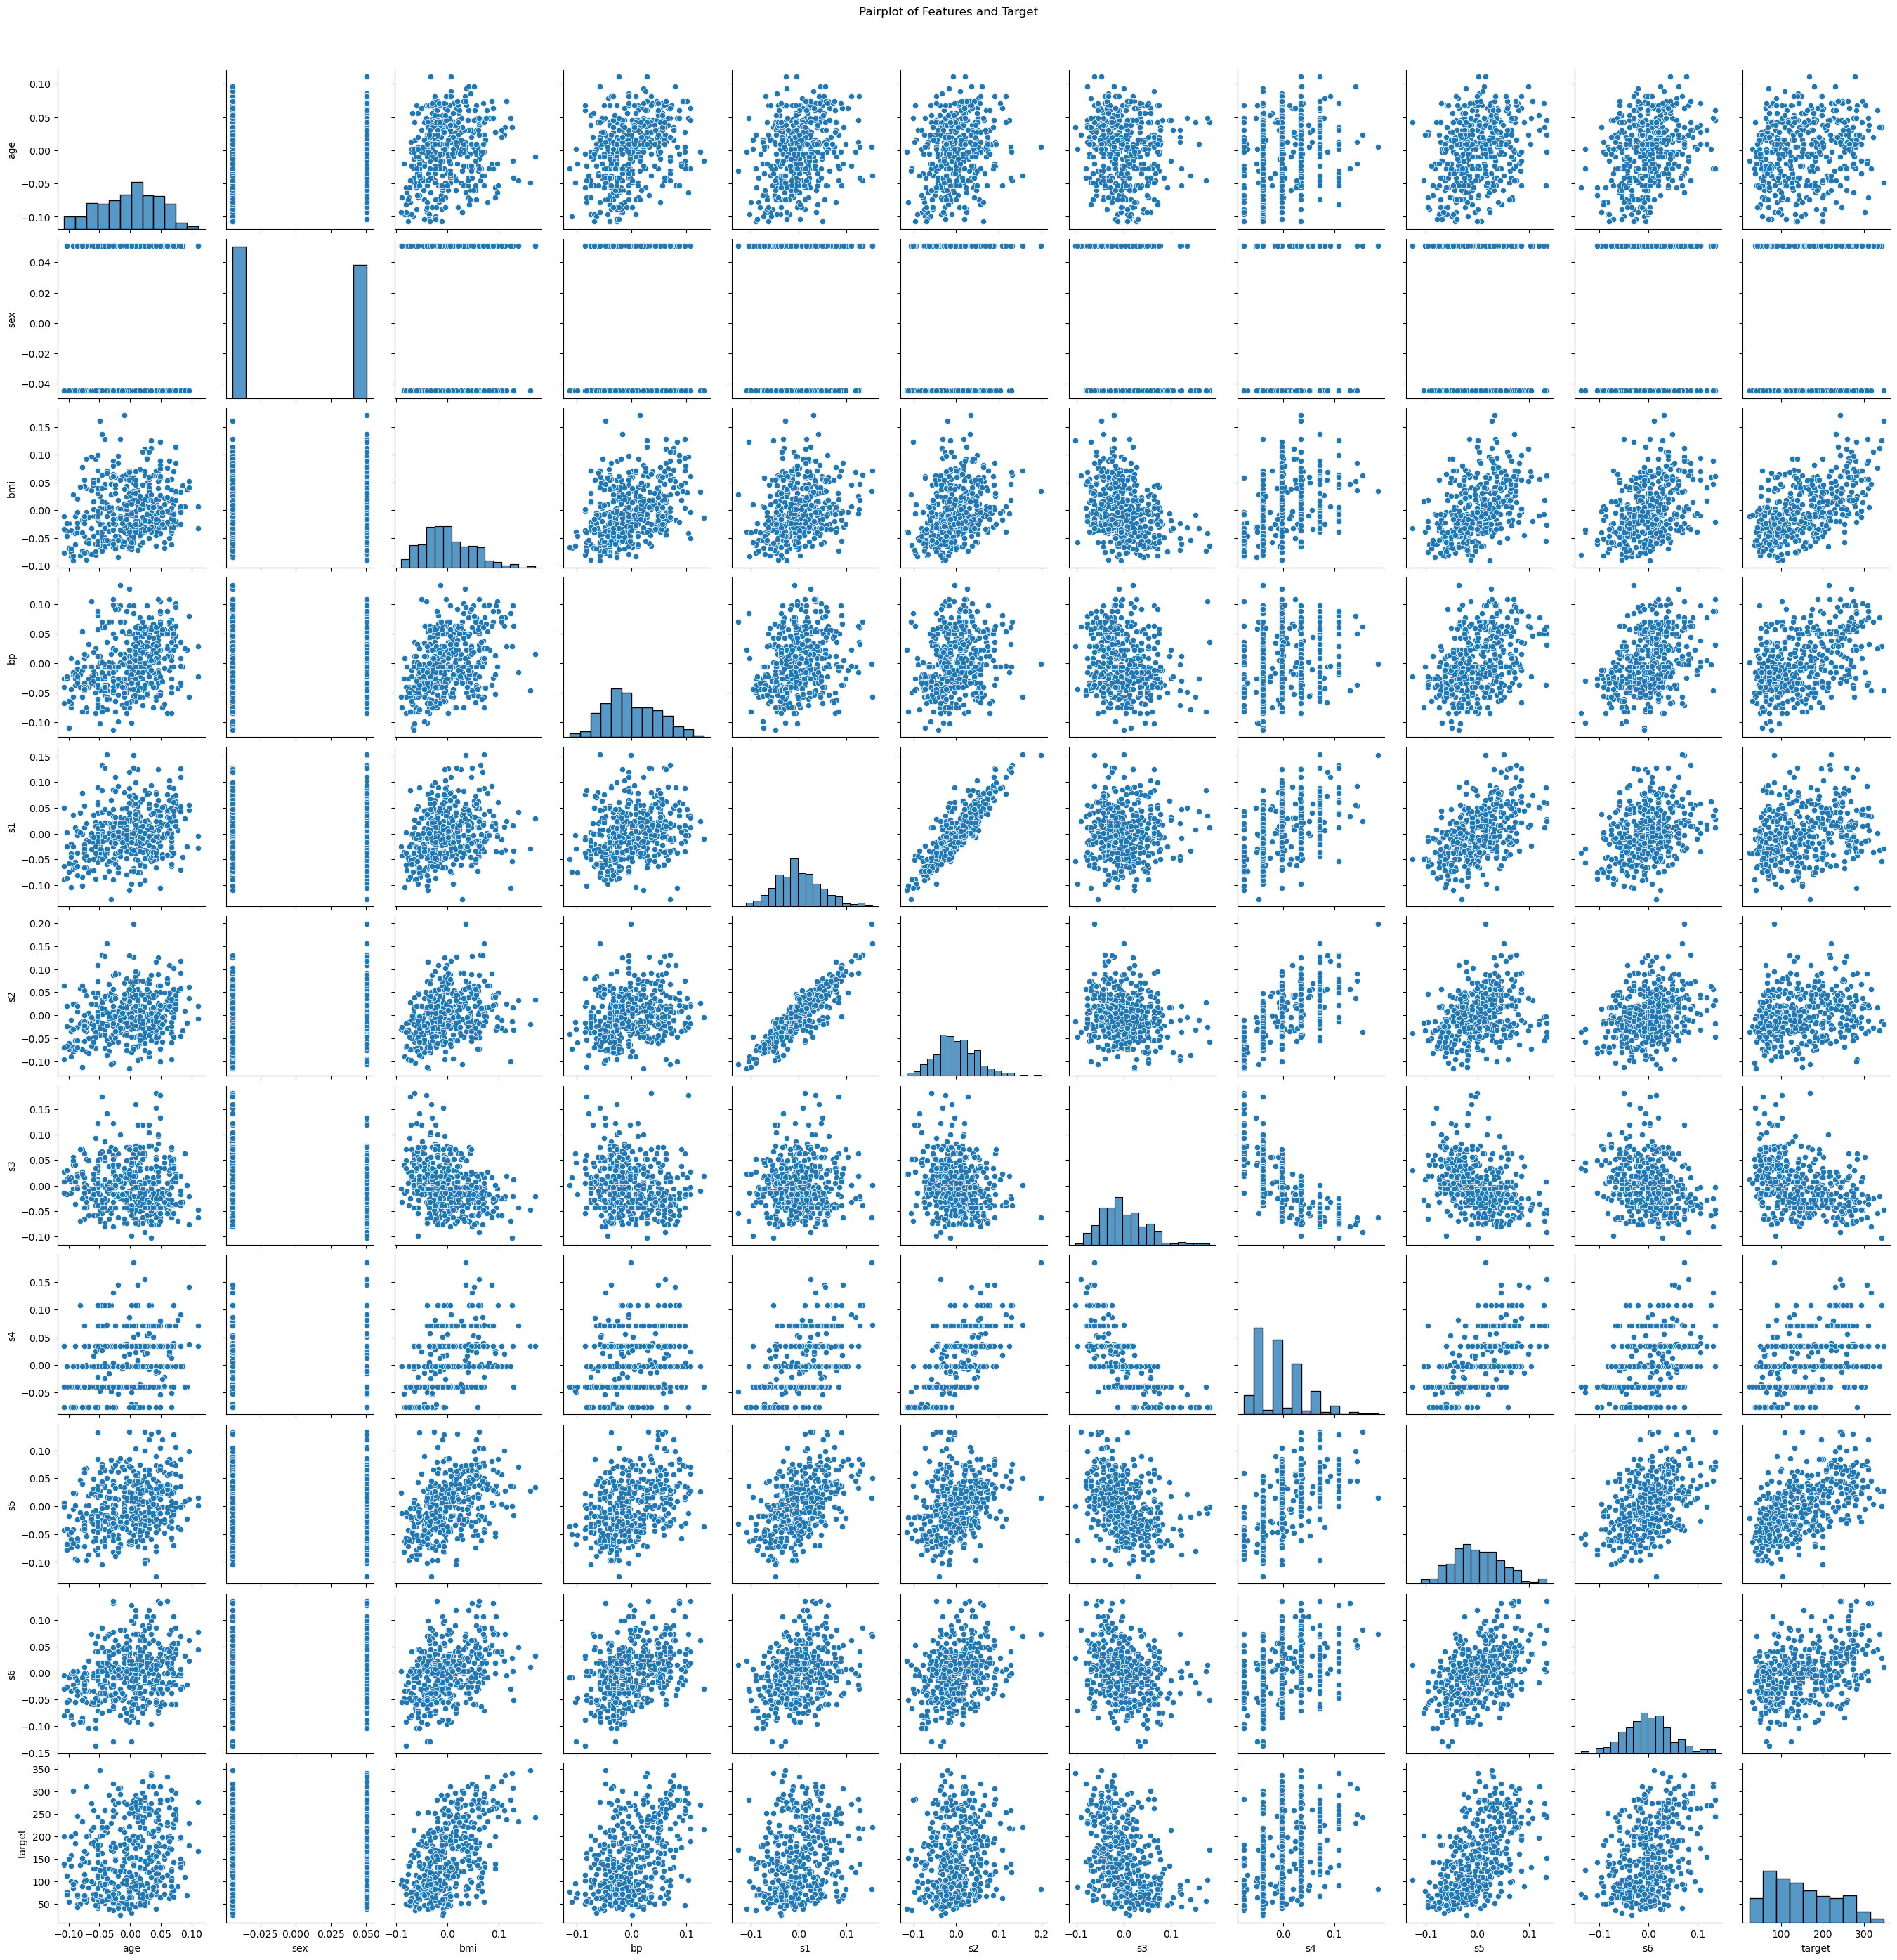

In [7]:
# Scatter plot to visualize relationships between features and target
sns.pairplot(df, height=2.5)
plt.suptitle("Pairplot of Features and Target", y=1.02)
plt.show()

In [13]:
# 3. Building the ANN Model
# Define the ANN model architecture
from tensorflow.keras import Input
model = Sequential([
    Input(shape=(X_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
# Compiling the model
model.compile(optimizer=Adam(), loss='mean_squared_error')

In [15]:
# 4. Training the ANN Model
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Training the model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, verbose=0)


In [17]:
# 5. Evaluating the Model
# To Make predictions on the testing data
y_pred = model.predict(X_test)

# To Calculate Mean Squared Error and R² Score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Mean Squared Error: 2794.4292070541146
R² Score: 0.47256527564796336


In [24]:
# 6. Improving the Model
# First will experiment with different architectures and activation functions
# Then will try adding more hidden layers and adjusting the number of neurons

# New model with an additional hidden layer and different neurons
improved_model = Sequential()
improved_model.add(Input(shape=(X_scaled.shape[1],)))  # Define input shape explicitly
improved_model.add(Dense(128, activation='relu'))  # 1st hidden layer
improved_model.add(Dense(64, activation='relu'))  # 2nd hidden layer
improved_model.add(Dense(32, activation='relu'))  # 3rd hidden layer
improved_model.add(Dense(1))  # Output layer

# Compiling the improved model
improved_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Training the improved model
improved_model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, verbose=0)

# Evaluating the improved model
y_pred_improved = improved_model.predict(X_test)

# Calculating Mean Squared Error and R² Score for the improved model
mse_improved = mean_squared_error(y_test, y_pred_improved)
r2_improved = r2_score(y_test, y_pred_improved)

print(f"Improved Mean Squared Error: {mse_improved}")
print(f"Improved R² Score: {r2_improved}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Improved Mean Squared Error: 2805.4247297436664
Improved R² Score: 0.47048992499523234


In [26]:
# Comparing the original and improved models
if mse_improved < mse:
    print("The improved model has a lower MSE, indicating better performance.")
else:
    print("The original model is performing better.")

The original model is performing better.


In [ ]:
After loading and preprocessing the data, a heatmap is generated to visualize correlations between features and a pairplot is created to visually inspect the relationships between features and the target variable.
To building the ANN Model, a simple neural network is created with one hidden layer (64 neurons). 
ReLU activation functions are used for the hidden layers, and the output layer is linear, appropriate for a regression task.
The data is split into training and testing sets (80% training, 20% testing).
The model is trained using the Adam optimizer and Mean Squared Error as the loss function.

The model is enhanced by adding more hidden layers and adjusting the number of neurons.
The improved model is trained and evaluated again, and the results are compared with the original model.